In [1]:
import tensorflow as tf
import requests
import zipfile
import os
import shutil
import random
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

## Step 1: Download and build the filtered dataset

In [3]:
MS_URL = 'https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip'
ZIP_PATH = 'kagglecatsanddogs_5340.zip'
RAW_DIR = 'PetImages_raw'
FILTERED_DIR = 'cats_and_dogs_filtered'

if not os.path.exists(ZIP_PATH):
    print("Downloading (~786MB, may take a few minutes)...")
    response = requests.get(MS_URL, stream=True)
    response.raise_for_status()
    with open(ZIP_PATH, 'wb') as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            f.write(chunk)
    print("Download complete.")
else:
    print("Zip already exists, skipping download.")

if not os.path.exists(RAW_DIR):
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(RAW_DIR)
    print("Extraction complete.")

cat_src = os.path.join(RAW_DIR, 'PetImages', 'Cat')
dog_src = os.path.join(RAW_DIR, 'PetImages', 'Dog')

random.seed(42)

def valid_images(folder, n):
    files = [f for f in os.listdir(folder) if f.lower().endswith('.jpg')]
    random.shuffle(files)
    picked = []
    for f in files:
        full_path = os.path.join(folder, f)
        if os.path.getsize(full_path) > 0:
            picked.append(f)
        if len(picked) == n:
            break
    return picked

def build_split(src_dir, class_name, n_train, n_val):
    files = valid_images(src_dir, n_train + n_val)
    train_files = files[:n_train]
    val_files = files[n_train:]

    train_out = os.path.join(FILTERED_DIR, 'train', class_name)
    val_out = os.path.join(FILTERED_DIR, 'validation', class_name)
    os.makedirs(train_out, exist_ok=True)
    os.makedirs(val_out, exist_ok=True)

    for f in train_files:
        shutil.copy(os.path.join(src_dir, f), os.path.join(train_out, f))
    for f in val_files:
        shutil.copy(os.path.join(src_dir, f), os.path.join(val_out, f))

if not os.path.exists(FILTERED_DIR):
    print("Building filtered subset (1000 train / 500 val per class)...")
    build_split(cat_src, 'cats', 1000, 500)
    build_split(dog_src, 'dogs', 1000, 500)
    print("Filtered subset ready.")
else:
    print("Filtered subset already exists, skipping.")

train_dir = os.path.join(FILTERED_DIR, 'train')
validation_dir = os.path.join(FILTERED_DIR, 'validation')
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')

print("Dataset ready at:", FILTERED_DIR)
print("Num train cat images:", len(os.listdir(train_cats_dir)))
print("Num train dog images:", len(os.listdir(train_dogs_dir)))

Zip already exists, skipping download.
Filtered subset already exists, skipping.
Dataset ready at: cats_and_dogs_filtered
Num train cat images: 932
Num train dog images: 931


## Step 2: Remove corrupt/invalid images (must run BEFORE loading the dataset)

In [4]:
num_skipped = 0

for subset in ('train', 'validation'):
    for class_name in ('cats', 'dogs'):
        folder_path = os.path.join(FILTERED_DIR, subset, class_name)
        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)
            try:
                with open(fpath, 'rb') as fobj:
                    is_jfif = b'JFIF' in fobj.peek(10)
            except Exception:
                is_jfif = False

            if not is_jfif:
                num_skipped += 1
                os.remove(fpath)

print(f"Deleted {num_skipped} corrupt/invalid images")

Deleted 0 corrupt/invalid images


## Step 3: Load the dataset (run this fresh, only once per kernel session)

In [5]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 20

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

class_names = train_dataset.class_names
print("Classes:", class_names)  # should print ['cats', 'dogs']

Found 1863 files belonging to 2 classes.
Found 927 files belonging to 2 classes.
Classes: ['cats', 'dogs']


## Step 4: Normalize pixel values (0-255 -> 0-1)\n\n**Important: only run this cell ONCE.** If you re-run it without reloading the dataset in Step 3 first, pixel values get divided by 255 a second time, crushing every image to near-zero and killing training (this is very likely what caused the earlier stuck-at-50% run).

In [6]:
normalization_layer = layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

## Step 5: Sanity check — confirm normalization worked before building the model

In [7]:
for images, labels in train_dataset.take(1):
    print("Pixel range:", images.numpy().min(), "to", images.numpy().max())
    print("Labels in this batch:", labels.numpy().flatten())

# Expect: pixel range close to 0.0 to 1.0, and a mix of 0s and 1s in labels.
# If pixel range is near 0.0 to 0.004, Step 4 ran twice -- restart the kernel and re-run from Step 3.

Pixel range: 0.0 to 1.0
Labels in this batch: [1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1.]


## Step 6: Build the CNN

In [14]:
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Compile

In [15]:
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # was 1e-4
    metrics=['accuracy']
)

## Step 8: Quick sanity-check training run (optional but recommended)\n\nBefore committing to a full 15-epoch run, check the model can learn on a tiny slice of data. It should reach high accuracy quickly on ~40 memorized images — if it stays near 50% here too, something upstream (Step 3-5) is still broken.

In [16]:
tiny_train = train_dataset.take(2)  # ~40 images
model.fit(tiny_train, epochs=20, verbose=1)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 216ms/step - accuracy: 0.5250 - loss: 0.7068
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.4750 - loss: 0.7181
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - accuracy: 0.5000 - loss: 0.7426
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.4000 - loss: 0.7009
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.5500 - loss: 0.6886
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - accuracy: 0.5500 - loss: 0.6858
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step - accuracy: 0.5000 - loss: 0.6881
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - accuracy: 0.5500 - loss: 0.6847
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.6000 - loss: 0.6652
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step - accuracy: 0.5000 - loss: 0.7039
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.3250 - loss: 0.7116
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - accuracy: 0.5500 - lo

## Step 9: Full training run\n\n**If you ran Step 8, restart the kernel and re-run Steps 3-7 first** so the model and dataset start fresh (Step 8 will have already updated the model's weights on the tiny slice).

In [17]:
history = model.fit(
    train_dataset,
    epochs=15,
    validation_data=validation_dataset
)

Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 257ms/step - accuracy: 0.5577 - loss: 0.6819 - val_accuracy: 0.5912 - val_loss: 0.6598
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 326ms/step - accuracy: 0.6162 - loss: 0.6384 - val_accuracy: 0.6257 - val_loss: 0.6409
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 287ms/step - accuracy: 0.6409 - loss: 0.6341 - val_accuracy: 0.6656 - val_loss: 0.6385
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 299ms/step - accuracy: 0.6999 - loss: 0.5807 - val_accuracy: 0.6580 - val_loss: 0.6167
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 30s 320ms/step - accuracy: 0.6989 - loss: 0.5679 - val_accuracy: 0.7335 - val_loss: 0.5801
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 338ms/step - accuracy: 0.7364 - loss: 0.5252 - val_accuracy: 0.7109 - val_loss: 0.6419
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 327ms/step - accuracy: 0.7354 - loss: 0.5234 - val_accuracy: 0.7001 - val_loss: 0.5981
Epoch 8/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 30s 319ms/step - accuracy: 0.7810 - loss: 0.4742 - val_accu

## Step 10: Plot accuracy and loss curves

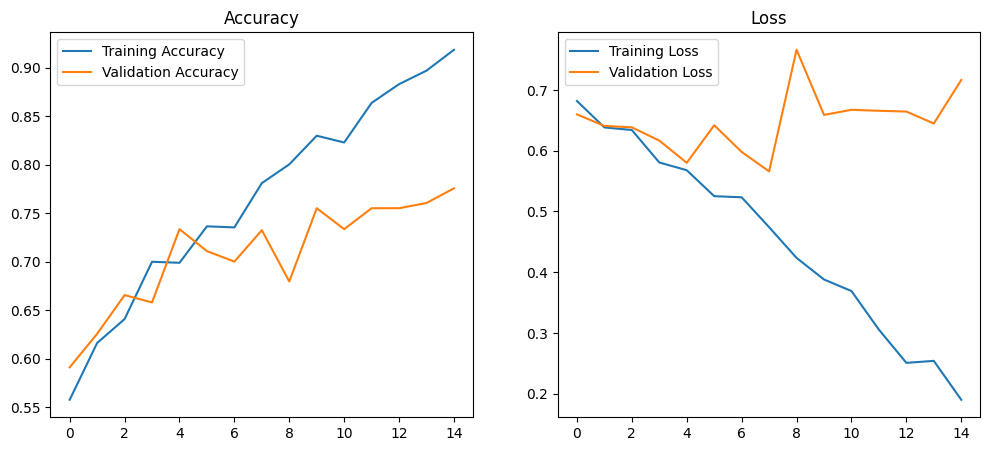

In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [11]:
test_model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

test_model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # default LR, no dropout
    metrics=['accuracy']
)

tiny_train = train_dataset.take(2)
test_model.fit(tiny_train, epochs=20, verbose=1)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 192ms/step - accuracy: 0.4750 - loss: 2.3020
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.6250 - loss: 1.2246
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.5750 - loss: 0.7843
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.4750 - loss: 0.6955
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5500 - loss: 0.6803
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - accuracy: 0.6250 - loss: 0.6563
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.5250 - loss: 0.7312
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 0.6000 - loss: 0.6747
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 0.4250 - loss: 0.6993
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.7000 - loss: 0.6367
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.7250 - loss: 0.6393
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.6750 - lo

In [33]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

def predict_image(img_path):
    # Load and resize to match training input size
    img = load_img(img_path, target_size=(150, 150))
    img_array = img_to_array(img)
    img_array = img_array / 255.0  # same normalization as training
    img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

    prediction = model.predict(img_array, verbose=0)[0][0]

    if prediction > 0.5:
        label = "Dog"
        confidence = prediction
    else:
        label = "Cat"
        confidence = 1 - prediction

    print(f"Prediction: {label} ({confidence*100:.1f}% confidence)")

    # Show the image alongside the prediction
    plt.imshow(img)
    plt.title(f"{label} ({confidence*100:.1f}%)")
    plt.axis('off')
    plt.show()

Prediction: Dog (99.5% confidence)


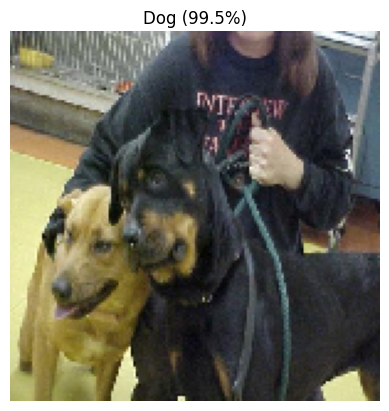

In [39]:
import os
sample_dog = os.path.join(validation_dir, 'dogs', os.listdir(os.path.join(validation_dir, 'dogs'))[20])
predict_image(sample_dog)

Prediction: Cat (99.9% confidence)


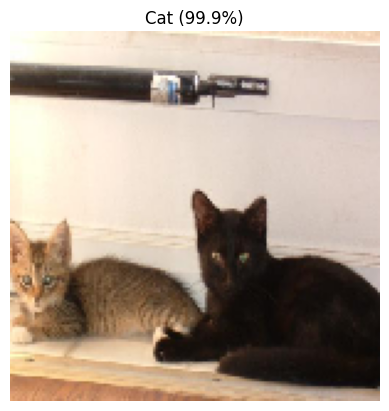

In [42]:
import os
sample_cat = os.path.join(validation_dir, 'cats', os.listdir(os.path.join(validation_dir, 'cats'))[20])
predict_image(sample_cat)

In [43]:
model.save('cats_vs_dogs_model.keras')
print("Model saved.")

Model saved.
